# BrushCue Example: 9:16 Crop

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/crop_9_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/crop-9-16

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


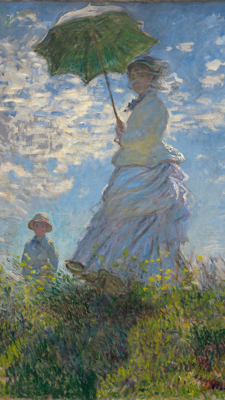

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
bounds = input_image.bounds()
w = bounds.width()
h = bounds.height()
crop_w = bc.Float.min(w, (h * (9.0 / 16.0)))
position = 0.5
crop_x = bounds.min_x() + ((w - crop_w) * position)
crop_h = bc.Float.min(h, (w / (9.0 / 16.0)))
crop_y = bounds.min_y() + ((h - crop_h) * position)
graph = input_image.crop(
    bc.Bounds2f.from_x_y_width_height(crop_x, crop_y, crop_w, crop_h)
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
